# Reject Then Cluster: Variance-Based Selective Clustering

Sort test points by uncertainty (ascending), keep the most confident X%,
then cluster **only the kept subset**. The clustering algorithm sees a
cleaner input, which should improve cluster quality.

Evaluates both **discard** mode (metrics on kept subset only) and
**garbage** mode (metrics on all points — rejected points count as errors).
Reports Precision, Recall, and F1 at the 0.9 threshold.

Uncertainty sources:
- **UG / Bern-NT+UG**: `variance.mean(axis=1)` (aleatoric)
- **LLA**: `variance.mean(axis=1)` (epistemic)
- **PCL**: `1/kappa` (aleatoric)
- **NL, Hinge, Bern-NT**: random ordering (deterministic, no uncertainty)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.mixture import BayesianGaussianMixture
from sklearn.decomposition import PCA

from embedders.base import EmbeddingResult
from clustering.greedy_kmedoid import GreedyKMedoidClusterer
from evaluation.eval_utils import (
    compute_class_center_medium_similarity,
    count_high_quality_clusters,
)

# ── Config ──
SEED         = 26042024
MODEL_DIR    = '../../models/notebook/unlabeled_exp'
EMB_DIR      = os.path.join(MODEL_DIR, 'embeddings')
METRIC       = 'l2'
MIN_BIN_SIZE = 5

MODEL_NAMES = ['nl', 'hinge', 'bern_nt', 'ug', 'ug_bnt', 'pcl', 'lla']
MODEL_LABELS = {
    'nl': 'NonLinear', 'hinge': 'Hinge', 'bern_nt': 'Bern-NT',
    'ug': 'UncertainGen', 'ug_bnt': 'Bern-NT+UG',
    'pcl': 'PCL', 'lla': 'LLA',
}
MODEL_COLORS = {
    'nl': 'gray', 'hinge': 'tab:purple', 'bern_nt': 'tab:olive',
    'ug': 'tab:red', 'ug_bnt': 'tab:cyan',
    'pcl': 'tab:blue', 'lla': 'tab:orange',
}
MODEL_MARKERS = {
    'nl': 'x', 'hinge': 'D', 'bern_nt': 'P',
    'ug': 'o', 'ug_bnt': 'v',
    'pcl': 's', 'lla': '^',
}

COVERAGES = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]

# Best hyperparameters from clustering_evaluation.ipynb
BEST_K_KMEANS = {
    'nl': 500, 'hinge': 450, 'bern_nt': 500,
    'ug': 500, 'ug_bnt': 500,
    'pcl': 500, 'lla': 500,
}
BEST_PCA_DIM = 16  # Best for DPGMM across all models
DPGMM_MAX_COMPONENTS = 500

print(f'Coverages: {COVERAGES}')

Coverages: [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]


## 1. Load Embeddings

In [2]:
def load_embedding(name, split):
    path = os.path.join(EMB_DIR, f'{name}_{split}.npz')
    data = np.load(path)
    return EmbeddingResult(
        mean=data['mean'],
        variance=data['variance'] if 'variance' in data else None,
        kappa=data['kappa'] if 'kappa' in data else None,
    )

val_embs  = {m: load_embedding(m, 'val')  for m in MODEL_NAMES}
test_embs = {m: load_embedding(m, 'test') for m in MODEL_NAMES}

val_labels  = np.load(os.path.join(EMB_DIR, 'val_labels.npy'))
test_labels = np.load(os.path.join(EMB_DIR, 'test_labels.npy'))
n_species   = len(set(val_labels.tolist()) | set(test_labels.tolist()))

print(f'Test: {len(test_labels)} samples, {n_species} species')

Test: 18639 samples, 323 species


## 2. Thresholds & Uncertainty

In [3]:
# Compute similarity thresholds from validation set (for Greedy KMedoid)
# Thresholds are computed WITHOUT variance/kappa — clustering is deterministic,
# variance is only used for rejection ordering.
thresholds = {}
scales = {}

for m in MODEL_NAMES:
    e = val_embs[m]
    kwargs = dict(metric=METRIC)
    if m == 'pcl':
        kwargs['kappas'] = e.kappa
        kwargs['k_form'] = 'cosine_direct'
        kwargs['alpha'] = 1.0

    pv, sc = compute_class_center_medium_similarity(
        e.point_estimate, val_labels, **kwargs)

    idx = -1 if m == 'pcl' else -3
    thresholds[m] = pv[idx]
    scales[m] = sc

# Define uncertainty per model
uncertainties = {}
rng = np.random.RandomState(SEED)
for m in MODEL_NAMES:
    e = test_embs[m]
    if m in ('ug', 'ug_bnt'):
        uncertainties[m] = e.variance.mean(axis=1)
    elif m == 'lla':
        uncertainties[m] = e.variance.mean(axis=1)
    elif m == 'pcl':
        uncertainties[m] = 1.0 / np.clip(e.kappa, 1e-6, None)
    else:
        uncertainties[m] = rng.rand(len(test_labels))

# Sort orders (ascending = most confident first)
sort_orders = {m: np.argsort(uncertainties[m]) for m in MODEL_NAMES}

print('Uncertainty sources:')
for m in MODEL_NAMES:
    src = 'mean(var)' if m in ('ug', 'ug_bnt', 'lla') else '1/kappa' if m == 'pcl' else 'random'
    print(f'  {MODEL_LABELS[m]:>12s}: {src}  '
          f'range=[{uncertainties[m].min():.5f}, {uncertainties[m].max():.5f}]')

Auto-calibrated scale: 2.325874 (median raw distance: 0.2980)
Percentile values: [0.13469695948590307, 0.2478129589322687, 0.3440444825228076, 0.42430783104547165, 0.49999996948309794, 0.5718823524604251, 0.6409133654115231, 0.7055413762306159, 0.7809424521158268]
Auto-calibrated scale: 7.413558 (median raw distance: 0.0935)
Percentile values: [0.15069984065974498, 0.2547610869942971, 0.34646003973295564, 0.42783402049195346, 0.49999999760358044, 0.5692493707381968, 0.6369857024645751, 0.7022794414774678, 0.7757844747543642]
Auto-calibrated scale: 4.238681 (median raw distance: 0.1635)
Percentile values: [0.17796589256655931, 0.27335453179281033, 0.3534285942876704, 0.4296497934761457, 0.49999999153659946, 0.5665567159372588, 0.6272561337349393, 0.6897571401125998, 0.7551181296674315]
Auto-calibrated scale: 2.325874 (median raw distance: 0.2980)
Percentile values: [0.13469695948590307, 0.2478129589322687, 0.3440444825228076, 0.42430783104547165, 0.49999996948309794, 0.5718823524604251,

## 3. Greedy KMedoid vs Coverage

At each coverage level, keep only the most confident points, build a new
`EmbeddingResult`, and run `GreedyKMedoidClusterer` on the subset.

In [4]:
greedy_curves = {m: [] for m in MODEL_NAMES}
N = len(test_labels)

for m in MODEL_NAMES:
    e = test_embs[m]
    order = sort_orders[m]
    print(f'\n{MODEL_LABELS[m]}:')

    for cov in COVERAGES:
        k_keep = max(1, int(N * cov))
        keep = order[:k_keep]

        # Build subset EmbeddingResult
        sub_mean = e.mean[keep]
        sub_kappa = e.kappa[keep] if e.kappa is not None else None
        # Clustering is deterministic — variance is only used for rejection ordering
        sub_emb = EmbeddingResult(mean=sub_mean, variance=None, kappa=sub_kappa)

        kwargs = dict(metric=METRIC, min_bin_size=MIN_BIN_SIZE, scale=scales[m])
        if m == 'pcl':
            kwargs['k_form'] = 'cosine_direct'
            kwargs['alpha'] = 1.0

        gkmed = GreedyKMedoidClusterer(**kwargs)
        pred = gkmed.fit_predict(sub_emb, min_similarity=thresholds[m])

        sub_labels = test_labels[keep]

        # ── Discard mode ──
        r_discard = count_high_quality_clusters(sub_labels, pred, mode="discard")

        # ── Garbage mode ──
        assigned_mask = pred != -1
        full_pred = np.full(N, -1, dtype=int)
        full_pred[keep[assigned_mask]] = pred[assigned_mask]
        r_garbage = count_high_quality_clusters(test_labels, full_pred, mode="garbage")

        n_clusters = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
        assigned = int((pred != -1).sum())

        greedy_curves[m].append({
            'coverage': cov, 'n_keep': k_keep,
            'k': n_clusters, 'assigned': assigned,
            'r': r_discard, 'r_garbage': r_garbage,
        })
        print(f'  cov={cov:.0%}  n={k_keep:5d}  k={n_clusters:4d}  '
              f'assigned={assigned:5d}  '
              f'F1>0.9={r_discard["counts"][8]:3d}  '
              f'F1>0.9(g)={r_garbage["counts"][8]:3d}')


NonLinear:


KeyboardInterrupt: 

## 4. KMeans vs Coverage

Uses the best k per model (from the full-data sweep in `clustering_evaluation.ipynb`).
At each coverage level, KMeans is re-run on the confident subset.

In [ ]:
kmeans_curves = {m: [] for m in MODEL_NAMES}

for m in MODEL_NAMES:
    order = sort_orders[m]
    best_k = BEST_K_KMEANS[m]
    print(f'\n{MODEL_LABELS[m]} (k={best_k}):')

    for cov in COVERAGES:
        k_keep = max(1, int(N * cov))
        keep = order[:k_keep]
        X = test_embs[m].point_estimate[keep]

        # Adjust k if subset is smaller
        k_use = min(best_k, k_keep)
        km = KMeans(n_clusters=k_use, random_state=SEED, n_init=5, max_iter=300)
        pred = km.fit_predict(X)

        bin_counts = Counter(pred)
        small = {c for c, n in bin_counts.items() if n < MIN_BIN_SIZE}
        if small:
            pred = np.where(np.isin(pred, list(small)), -1, pred)

        sub_labels = test_labels[keep]

        # ── Discard mode ──
        r_discard = count_high_quality_clusters(sub_labels, pred, mode="discard")

        # ── Garbage mode ──
        assigned_mask = pred != -1
        full_pred = np.full(N, -1, dtype=int)
        full_pred[keep[assigned_mask]] = pred[assigned_mask]
        r_garbage = count_high_quality_clusters(test_labels, full_pred, mode="garbage")

        n_clusters = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
        assigned = int((pred != -1).sum())

        kmeans_curves[m].append({
            'coverage': cov, 'n_keep': k_keep,
            'k': n_clusters, 'assigned': assigned,
            'r': r_discard, 'r_garbage': r_garbage,
        })
        print(f'  cov={cov:.0%}  n={k_keep:5d}  k={n_clusters:4d}  '
              f'assigned={assigned:5d}  '
              f'F1>0.9={r_discard["counts"][8]:3d}  '
              f'F1>0.9(g)={r_garbage["counts"][8]:3d}')


NonLinear (k=500):
  cov=100%  n=18639  k= 500  assigned=18639  F1>0.9= 30  F1>0.9(g)= 30
  cov=90%  n=16775  k= 500  assigned=16775  F1>0.9= 29  F1>0.9(g)= 13
  cov=80%  n=14911  k= 499  assigned=14908  F1>0.9= 26  F1>0.9(g)=  2
  cov=70%  n=13047  k= 500  assigned=13047  F1>0.9= 28  F1>0.9(g)=  0
  cov=60%  n=11183  k= 495  assigned=11169  F1>0.9= 22  F1>0.9(g)=  0
  cov=50%  n= 9319  k= 490  assigned= 9288  F1>0.9= 27  F1>0.9(g)=  0
  cov=40%  n= 7455  k= 484  assigned= 7402  F1>0.9= 25  F1>0.9(g)=  0
  cov=30%  n= 5591  k= 456  assigned= 5453  F1>0.9= 30  F1>0.9(g)=  0
  cov=20%  n= 3727  k= 377  assigned= 3365  F1>0.9= 24  F1>0.9(g)=  0

Hinge (k=450):
  cov=100%  n=18639  k= 449  assigned=18635  F1>0.9= 55  F1>0.9(g)= 55
  cov=90%  n=16775  k= 450  assigned=16775  F1>0.9= 52  F1>0.9(g)= 23
  cov=80%  n=14911  k= 450  assigned=14911  F1>0.9= 53  F1>0.9(g)=  2
  cov=70%  n=13047  k= 450  assigned=13047  F1>0.9= 47  F1>0.9(g)=  1
  cov=60%  n=11183  k= 445  assigned=11168  F1>0.9= 

## 5. DPGMM vs Coverage

BayesianGaussianMixture with PCA=16 (best from full-data experiment).
Re-fit at each coverage level on the confident subset.

In [ ]:
dpgmm_curves = {m: [] for m in MODEL_NAMES}

for m in MODEL_NAMES:
    order = sort_orders[m]
    print(f'\n{MODEL_LABELS[m]}:')

    for cov in COVERAGES:
        k_keep = max(1, int(N * cov))
        keep = order[:k_keep]
        X = test_embs[m].point_estimate[keep]

        pca_dim = min(BEST_PCA_DIM, X.shape[0] - 1, X.shape[1])
        X_pca = PCA(n_components=pca_dim, random_state=SEED).fit_transform(X)

        n_comp = min(DPGMM_MAX_COMPONENTS, k_keep - 1)
        bgm = BayesianGaussianMixture(
            n_components=n_comp,
            covariance_type='diag',
            weight_concentration_prior_type='dirichlet_distribution',
            weight_concentration_prior=1000,
            random_state=SEED,
            max_iter=500,
            n_init=1,
        )
        pred = bgm.fit_predict(X_pca)

        bin_counts = Counter(pred)
        small = {c for c, n in bin_counts.items() if n < MIN_BIN_SIZE}
        if small:
            pred = np.where(np.isin(pred, list(small)), -1, pred)

        sub_labels = test_labels[keep]

        # ── Discard mode ──
        r_discard = count_high_quality_clusters(sub_labels, pred, mode="discard")

        # ── Garbage mode ──
        assigned_mask = pred != -1
        full_pred = np.full(N, -1, dtype=int)
        full_pred[keep[assigned_mask]] = pred[assigned_mask]
        r_garbage = count_high_quality_clusters(test_labels, full_pred, mode="garbage")

        n_clusters = len(set(pred[pred != -1].tolist())) if (pred != -1).any() else 0
        assigned = int((pred != -1).sum())

        dpgmm_curves[m].append({
            'coverage': cov, 'n_keep': k_keep,
            'k': n_clusters, 'assigned': assigned,
            'r': r_discard, 'r_garbage': r_garbage,
        })
        print(f'  cov={cov:.0%}  n={k_keep:5d}  k={n_clusters:4d}  '
              f'assigned={assigned:5d}  '
              f'F1>0.9={r_discard["counts"][8]:3d}  '
              f'F1>0.9(g)={r_garbage["counts"][8]:3d}')


NonLinear:


e:\gnome\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


  cov=100%  n=18639  k= 268  assigned=18563  F1>0.9= 63  F1>0.9(g)= 63
  cov=90%  n=16775  k= 264  assigned=16700  F1>0.9= 63  F1>0.9(g)= 25


e:\gnome\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


  cov=80%  n=14911  k= 254  assigned=14858  F1>0.9= 54  F1>0.9(g)=  3
  cov=70%  n=13047  k= 240  assigned=12969  F1>0.9= 53  F1>0.9(g)=  1
  cov=60%  n=11183  k= 227  assigned=11113  F1>0.9= 52  F1>0.9(g)=  0
  cov=50%  n= 9319  k= 220  assigned= 9188  F1>0.9= 51  F1>0.9(g)=  0
  cov=40%  n= 7455  k= 197  assigned= 7334  F1>0.9= 46  F1>0.9(g)=  0
  cov=30%  n= 5591  k= 187  assigned= 5464  F1>0.9= 40  F1>0.9(g)=  0
  cov=20%  n= 3727  k= 144  assigned= 3527  F1>0.9= 22  F1>0.9(g)=  0

Hinge:
  cov=100%  n=18639  k= 337  assigned=18558  F1>0.9= 82  F1>0.9(g)= 81
  cov=90%  n=16775  k= 306  assigned=16690  F1>0.9= 80  F1>0.9(g)= 40
  cov=80%  n=14911  k= 307  assigned=14818  F1>0.9= 86  F1>0.9(g)=  7
  cov=70%  n=13047  k= 297  assigned=12963  F1>0.9= 80  F1>0.9(g)=  2
  cov=60%  n=11183  k= 280  assigned=11089  F1>0.9= 82  F1>0.9(g)=  0
  cov=50%  n= 9319  k= 277  assigned= 9172  F1>0.9= 75  F1>0.9(g)=  0
  cov=40%  n= 7455  k= 245  assigned= 7344  F1>0.9= 68  F1>0.9(g)=  0
  cov=30%  

...

  cov=100%  n=18639  k= 335  assigned=18580  F1>0.9= 84  F1>0.9(g)= 82
  cov=90%  n=16775  k= 330  assigned=16702  F1>0.9= 83  F1>0.9(g)= 80
  cov=80%  n=14911  k= 311  assigned=14838  F1>0.9= 88  F1>0.9(g)= 79
  cov=70%  n=13047  k= 324  assigned=12910  F1>0.9= 92  F1>0.9(g)= 74
  cov=60%  n=11183  k= 278  assigned=11080  F1>0.9= 91  F1>0.9(g)= 57
  cov=50%  n= 9319  k= 250  assigned= 9138  F1>0.9= 86  F1>0.9(g)= 33
  cov=40%  n= 7455  k= 223  assigned= 7219  F1>0.9= 83  F1>0.9(g)= 18
  cov=30%  n= 5591  k= 185  assigned= 5358  F1>0.9= 77  F1>0.9(g)= 10
  cov=20%  n= 3727  k= 134  assigned= 3392  F1>0.9= 65  F1>0.9(g)=  4

LLA:
  cov=100%  n=18639  k= 277  assigned=18565  F1>0.9= 65  F1>0.9(g)= 62


e:\gnome\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


  cov=90%  n=16775  k= 257  assigned=16707  F1>0.9= 62  F1>0.9(g)= 42


e:\gnome\Lib\site-packages\sklearn\mixture\_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


  cov=80%  n=14911  k= 227  assigned=14830  F1>0.9= 47  F1>0.9(g)= 23
  cov=70%  n=13047  k= 214  assigned=12990  F1>0.9= 38  F1>0.9(g)=  9
  cov=60%  n=11183  k= 191  assigned=11103  F1>0.9= 39  F1>0.9(g)=  6
  cov=50%  n= 9319  k= 161  assigned= 9260  F1>0.9= 27  F1>0.9(g)=  2
  cov=40%  n= 7455  k= 132  assigned= 7359  F1>0.9= 27  F1>0.9(g)=  1
  cov=30%  n= 5591  k= 108  assigned= 5496  F1>0.9= 17  F1>0.9(g)=  1
  cov=20%  n= 3727  k=  65  assigned= 3569  F1>0.9= 10  F1>0.9(g)=  0


## 6. Comparison Plots

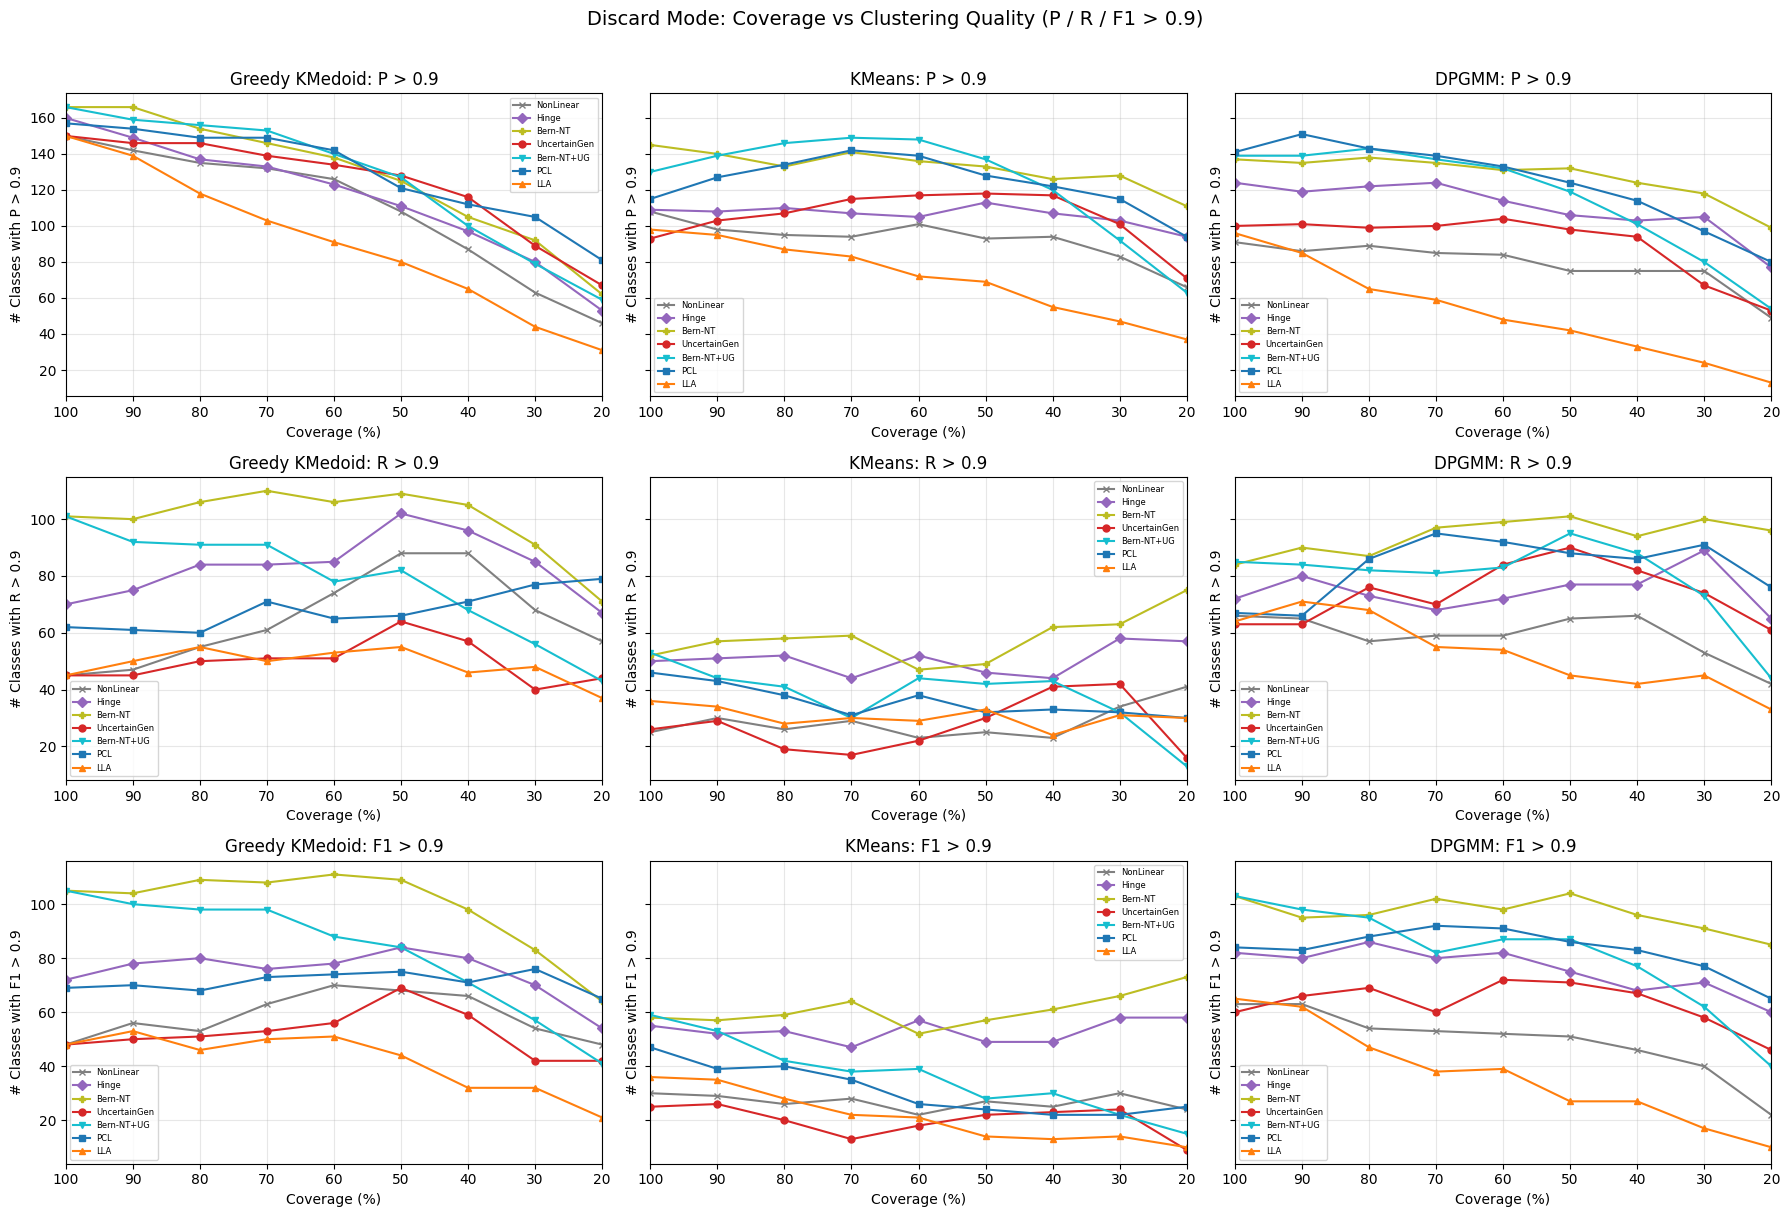

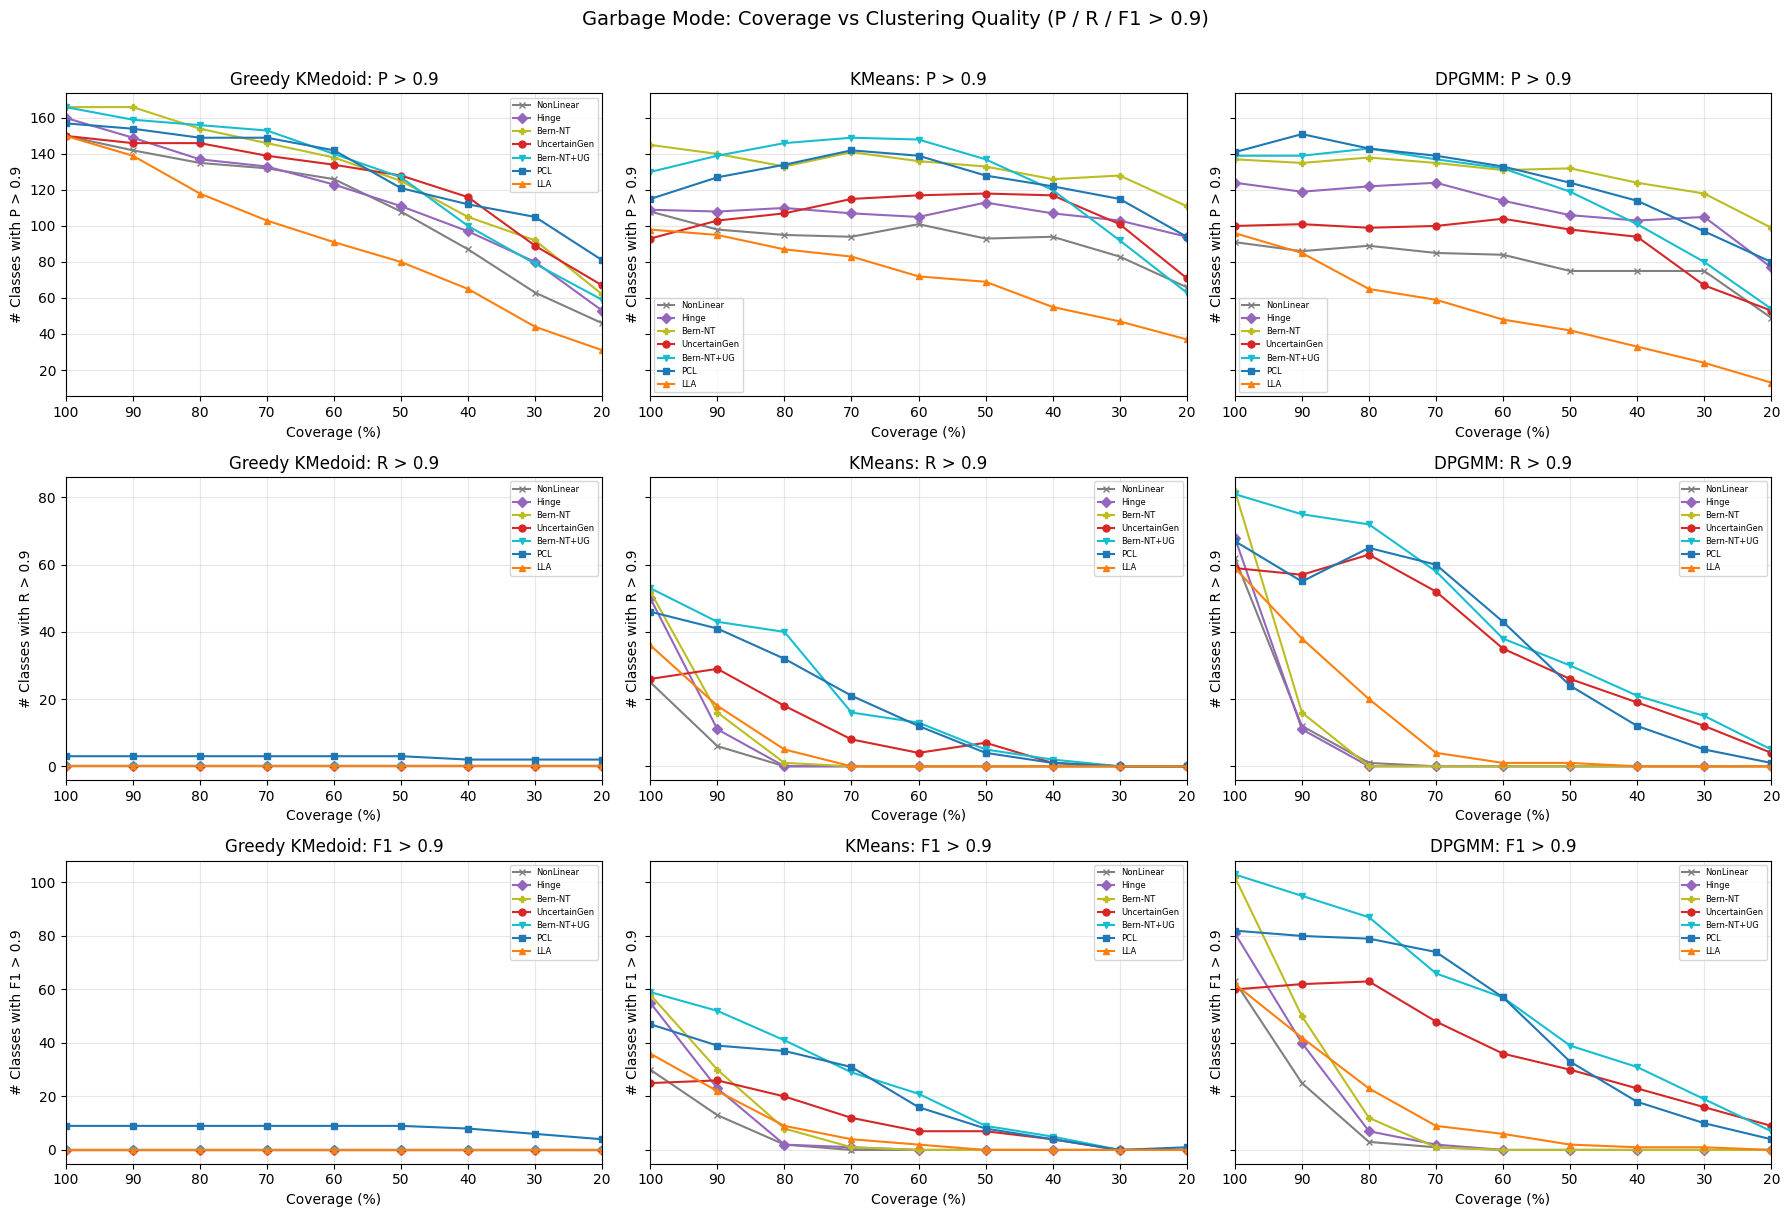

In [ ]:
method_curves = {
    'Greedy KMedoid': greedy_curves,
    'KMeans': kmeans_curves,
    'DPGMM': dpgmm_curves,
}
method_names = list(method_curves.keys())

metrics_to_plot = [
    ('precision_counts', 8, 'P > 0.9'),
    ('recall_counts',    8, 'R > 0.9'),
    ('f1_counts',        8, 'F1 > 0.9'),
]

for mode_label, r_key in [('Discard', 'r'), ('Garbage', 'r_garbage')]:
    fig, axes = plt.subplots(len(metrics_to_plot), 3, figsize=(18, 12), sharey='row')

    for col, method in enumerate(method_names):
        curves = method_curves[method]
        for row, (metric_key, idx, ylabel) in enumerate(metrics_to_plot):
            ax = axes[row, col]
            for m in MODEL_NAMES:
                covs = [r['coverage'] * 100 for r in curves[m]]
                vals = [r[r_key][metric_key][idx] for r in curves[m]]
                ax.plot(covs, vals, f'{MODEL_MARKERS[m]}-',
                        color=MODEL_COLORS[m], label=MODEL_LABELS[m], markersize=5)
            ax.set_xlabel('Coverage (%)')
            ax.set_ylabel(f'# Classes with {ylabel}')
            ax.set_title(f'{method}: {ylabel}')
            ax.legend(fontsize=6)
            ax.grid(True, alpha=0.3)
            ax.set_xlim(100, 20)

    plt.suptitle(f'{mode_label} Mode: Coverage vs Clustering Quality (P / R / F1 > 0.9)',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Summary Tables: P>0.9, R>0.9, F1>0.9 for both modes ──
for mode_label, r_key in [('DISCARD', 'r'), ('GARBAGE', 'r_garbage')]:
    print(f'\n{"=" * 40}')
    print(f'  Mode: {mode_label}')
    print(f'{"=" * 40}')

    for metric_label, metric_key, idx in [
        ('P>0.9',  'precision_counts', 8),
        ('R>0.9',  'recall_counts',    8),
        ('F1>0.9', 'f1_counts',        8),
    ]:
        print(f'\n  {metric_label}:')
        print(f'  {"Method":>15s}  {"Model":>12s}  ', end='')
        for cov in COVERAGES:
            print(f'  {cov:.0%}', end='')
        print()
        print(f'  {"-" * (30 + 6 * len(COVERAGES))}')

        for method in method_names:
            curves = method_curves[method]
            for m in MODEL_NAMES:
                print(f'  {method:>15s}  {MODEL_LABELS[m]:>12s}  ', end='')
                for entry in curves[m]:
                    print(f'  {entry[r_key][metric_key][idx]:3d}', end='')
                print()
            print()

# ── Compact comparison at 100% coverage ──
print(f'\n{"=" * 100}')
print(f'  Compact Summary at 100% Coverage')
print(f'{"=" * 100}')
print(f'  {"Method":>15s}  {"Model":>12s}  '
      f'{"P>.9":>5s}  {"R>.9":>5s}  {"F1>.9":>6s}  |  '
      f'{"P>.9(g)":>7s}  {"R>.9(g)":>7s}  {"F1>.9(g)":>8s}')
print(f'  {"-" * 95}')
for method in method_names:
    curves = method_curves[method]
    for m in MODEL_NAMES:
        r_d = curves[m][0]['r']        # coverage=1.0
        r_g = curves[m][0]['r_garbage']
        print(f'  {method:>15s}  {MODEL_LABELS[m]:>12s}  '
              f'{r_d["precision_counts"][8]:>5d}  '
              f'{r_d["recall_counts"][8]:>5d}  '
              f'{r_d["f1_counts"][8]:>6d}  |  '
              f'{r_g["precision_counts"][8]:>7d}  '
              f'{r_g["recall_counts"][8]:>7d}  '
              f'{r_g["f1_counts"][8]:>8d}')
    print()


  Mode: DISCARD

  P>0.9:
           Method         Model    100%  90%  80%  70%  60%  50%  40%  30%  20%
  ------------------------------------------------------------------------------------
   Greedy KMedoid     NonLinear    150  142  135  132  126  108   87   63   46
   Greedy KMedoid         Hinge    160  149  137  133  123  111   97   80   53
   Greedy KMedoid       Bern-NT    166  166  154  146  138  125  105   92   62
   Greedy KMedoid  UncertainGen    150  146  146  139  134  128  116   89   67
   Greedy KMedoid    Bern-NT+UG    166  159  156  153  140  127  100   79   59
   Greedy KMedoid           PCL    157  154  149  149  142  121  112  105   81
   Greedy KMedoid           LLA    150  139  118  103   91   80   65   44   31

           KMeans     NonLinear    108   98   95   94  101   93   94   83   66
           KMeans         Hinge    109  108  110  107  105  113  107  103   94
           KMeans       Bern-NT    145  140  133  141  136  133  126  128  111
           KMea